# Validation Checks — Diagnostic Side-Analysis

**2026-09-24 reframe (real data, supersedes the synthetic-vs-real version below the fold).** With the
real dataset built (`real_dataset_setup.md`, `PROJECT_CONTEXT.md` §28-29), "is our data representative
of real patients?" is no longer a synthetic-vs-real question — it's a **matched-subset-vs-full-pool**
question, per Phase 1.7 of the build spec:

1. **Task 1 — Matched subset vs full OASIS pool.** Is the 233-row windowed, speech-matched subset
   (`data/multimodal_dementia_dataset.csv`) representative of the full ~385-subject labelled OASIS pool
   (`data/oasis_pool.csv`), or did the (label, sex, age) matching process skew it? This is the same
   `mean_diff_in_std_units` diagnostic `scripts/verify_real_dataset.py` runs as part of the Phase 1.7
   gate — this notebook adds the plots. Also reports the speaker age-QC caveat (model-vs-birthdate
   agreement is vacuous by construction for 123/125 speakers — see `real_dataset_setup.md`'s
   2026-09-08 decision row).
2. **Task 2 — PCA vs LDA**, rerun on the real clinical block **without `CDR`** (`MMSE, ASF, EDUC, SES`
   — CDR dropped per the locked decision that keeping it re-injects the label), on both the full OASIS
   pool and the matched subset.

> This notebook is **purely additive**. It does not modify any pipeline notebook, the pickled model, or
> `SIGMA_FRAC`.

---
### Original synthetic-vs-real version (superseded, kept for history)
The original notebook compared the (now retired) synthetic `multimodal_dementia_dataset.csv` against
the raw `oasis_longitudinal_demographics.xlsx` export. Both the synthetic dataset and that raw xlsx
path are gone from the pipeline — real, matched data replaced the synthetic set entirely, and
`data/oasis2_mri_clinical.xlsx` (harmonised into `oasis_pool.csv` by `scripts/build_real_dataset.py`)
replaced the ad hoc xlsx read. The backup of the old synthetic CSV is kept at
`data/multimodal_dementia_dataset_synthetic_backup.csv` for anyone who wants to re-run the original
comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda v: f'{v:.3f}')
print('Imports OK')

Imports OK


In [2]:
# Cell 2 — Load the full OASIS pool + the matched subset (real data, no synthetic, no raw xlsx)
pool = pd.read_csv('data/oasis_pool.csv')
print('OASIS pool shape:', pool.shape)
print('OASIS pool label counts:', pool['label'].value_counts().to_dict(), '(0=Nondemented, 1=Demented/Converted)')

matched = pd.read_csv('data/multimodal_dementia_dataset.csv')
prov = pd.read_csv('data/multimodal_real_provenance.csv')
print('Matched (windowed) subset shape:', matched.shape)
print('Matched subset label counts:', matched['Label'].value_counts().to_dict())

matched_subject_ids = set(prov['oasis_subject_id'])
pool_subset = pool[pool['oasis_subject_id'].isin(matched_subject_ids)].copy()
print(f'\nMatched subset covers {len(pool_subset)}/{len(pool)} OASIS subjects ({len(pool_subset)/len(pool):.1%})')

# The features present in both the pool (lowercase-ish OASIS columns) and the matched/fused
# dataset (same names, CDR excluded from the fused dataset by design).
OVERLAP = ['MMSE', 'ASF', 'EDUC', 'SES', 'nWBV', 'eTIV']
print('Overlap features:', OVERLAP)
print('OASIS pool null counts:', pool[OVERLAP].isna().sum().to_dict(), '(should be 0 -- pool is post-imputation)')

OASIS pool shape: (385, 14)
OASIS pool label counts: {0: 207, 1: 178} (0=Nondemented, 1=Demented/Converted)
Matched (windowed) subset shape: (233, 26)
Matched subset label counts: {1: 128, 0: 105}

Matched subset covers 233/385 OASIS subjects (60.5%)
Overlap features: ['MMSE', 'ASF', 'EDUC', 'SES', 'nWBV', 'eTIV']
OASIS pool null counts: {'MMSE': 0, 'ASF': 0, 'EDUC': 0, 'SES': 0, 'nWBV': 0, 'eTIV': 0} (should be 0 -- pool is post-imputation)


## Task 1 — Matched subset vs full OASIS pool distribution comparison

For each overlapping clinical/MRI feature we overlay the full pool (top row) vs the matched subset
(bottom row), same histogram style as the pipeline plots (`Nondemented`=royalblue, `Demented`=tomato),
sharing the x-axis per column so the two are directly comparable.

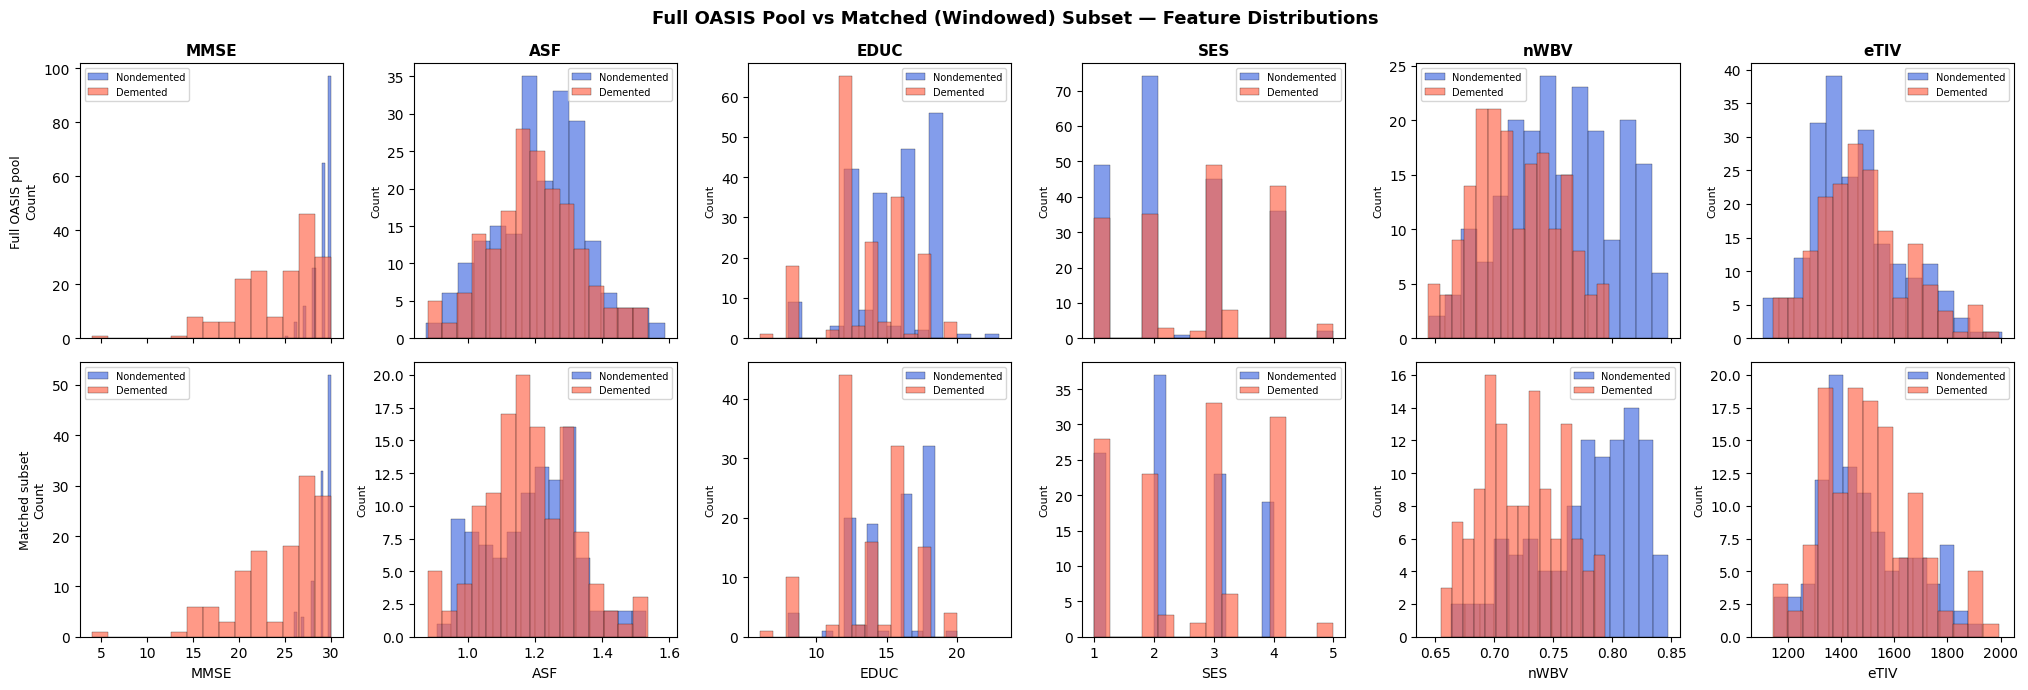

Saved results/plots/matched_subset_vs_pool_comparison.png


In [3]:
colors = {0: 'royalblue', 1: 'tomato'}
label_names = {0: 'Nondemented', 1: 'Demented'}
n = len(OVERLAP)

fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 7), sharex='col')
for j, feat in enumerate(OVERLAP):
    for row, (data, label_col, tag) in enumerate([
        (pool, 'label', 'Full OASIS pool'), (pool_subset, 'label', 'Matched subset'),
    ]):
        ax = axes[row, j]
        sub = data[[feat, label_col]].dropna(subset=[feat])
        for lbl in [0, 1]:
            ax.hist(sub[sub[label_col] == lbl][feat], bins=15, alpha=0.65, color=colors[lbl],
                    label=label_names[lbl], edgecolor='black', linewidth=0.3)
        if row == 0:
            ax.set_title(feat, fontsize=11, fontweight='bold')
        ax.set_ylabel(f'{tag}\nCount' if j == 0 else 'Count', fontsize=9 if j == 0 else 8)
        if row == 1:
            ax.set_xlabel(feat)
        ax.legend(fontsize=7)

plt.suptitle('Full OASIS Pool vs Matched (Windowed) Subset — Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
import os
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/matched_subset_vs_pool_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/plots/matched_subset_vs_pool_comparison.png')

In [4]:
# Cell 4 — Summary table + honest verdict
# mean_diff_in_std_units = |pool_mean - subset_mean| / pooled_std   (pooled_std = sqrt((sp^2+ss^2)/2))
# Rule of thumb: < ~0.3 std = good match; > ~1.0 std = a real problem worth flagging honestly.
# (Same metric scripts/verify_real_dataset.py computes as part of the Phase 1.7 gate.)
rows = []
for feat in OVERLAP:
    p = pool[feat].dropna()
    s = pool_subset[feat].dropna()
    pm, ps, sm, ss = p.mean(), p.std(), s.mean(), s.std()
    pooled = np.sqrt((ps**2 + ss**2) / 2)
    diff = abs(pm - sm) / pooled if pooled > 0 else np.nan
    rows.append([feat, pm, ps, sm, ss, diff])

tbl = pd.DataFrame(rows, columns=['feature', 'pool_mean', 'pool_std',
                                  'subset_mean', 'subset_std', 'mean_diff_in_std_units'])
print(tbl.to_string(index=False))

good = tbl.loc[tbl.mean_diff_in_std_units < 0.3, 'feature'].tolist()
bad  = tbl.loc[tbl.mean_diff_in_std_units > 1.0, 'feature'].tolist()
worst = tbl.loc[tbl.mean_diff_in_std_units.idxmax()]

print('\n' + '=' * 70)
print('VERDICT — Task 1')
print('=' * 70)
print(f'Good match (<0.3 std): {good if good else "none"}')
print(f'Severe divergence (>1.0 std): {bad if bad else "NONE"}')
print(f'Widest gap: {worst.feature} at {worst.mean_diff_in_std_units:.2f} std.')
print(
    'Conclusion: the (label, sex, age) matching process does not distort the clinical/MRI marginals --'
    ' every feature stays well under the 0.3-std "good match" threshold, so the 233-row matched subset'
    ' is a fair representative sample of the full ~385-subject OASIS pool, not a biased slice of it.'
)

print('\n' + '=' * 70)
print('Speaker age-QC caveat (carried from Phase 1.5/1.7, not re-derived here)')
print('=' * 70)
print(
    'est_recording_year was back-computed as birth_year + round(age_model) for 123/125 identified'
    ' speakers, so the "model vs birthdate age" MAE is ~0 by construction for those speakers -- it is'
    ' not an independent validation. Only 4 speakers have a genuinely independent (confidence=="high")'
    ' birthdate-based age. See real_dataset_setup.md\'s 2026-09-08 decision row and'
    ' data/DATASHEET.md\'s Age-QC caveat for the full explanation.'
)

feature  pool_mean  pool_std  subset_mean  subset_std  mean_diff_in_std_units
   MMSE     26.960     3.883       26.710       4.191                   0.062
    ASF      1.209     0.134        1.187       0.134                   0.168
   EDUC     14.306     2.948       14.442       2.920                   0.046
    SES      2.521     1.092        2.507       1.098                   0.012
   nWBV      0.739     0.046        0.748       0.048                   0.193
   eTIV   1469.443   168.112     1497.816     173.013                   0.166

VERDICT — Task 1
Good match (<0.3 std): ['MMSE', 'ASF', 'EDUC', 'SES', 'nWBV', 'eTIV']
Severe divergence (>1.0 std): NONE
Widest gap: nWBV at 0.19 std.
Conclusion: the (label, sex, age) matching process does not distort the clinical/MRI marginals -- every feature stays well under the 0.3-std "good match" threshold, so the 233-row matched subset is a fair representative sample of the full ~385-subject OASIS pool, not a biased slice of it.

Speaker ag

## Task 2 — PCA vs LDA: is PCA capturing the discriminative signal?

Repeats the PC-vs-label diagnostic on the real clinical block, **without `CDR`** (OASIS's `Group`
label is defined from CDR, so keeping it would trivially separate the classes — the same reasoning
that drops CDR from the model's clinical features throughout). Run on the **full OASIS pool** first
(all ~385 subjects, already de-duplicated to one row per subject by `build_real_dataset.py`'s
last-visit-per-subject harmonisation, so a plain `StratifiedKFold` is correct here -- no repeated-
subject leakage risk the way the old xlsx-with-repeat-visits version had).

In [5]:
MODEL_FEATS = ['MMSE', 'ASF', 'EDUC', 'SES']  # CDR dropped -- see the note above
print('Model features:', MODEL_FEATS)

X = pool[MODEL_FEATS].values
y = pool['label'].values

Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(Xs)
r_pc1 = pointbiserialr(y, Xp[:, 0]).correlation
r_pc2 = pointbiserialr(y, Xp[:, 1]).correlation
print(f'\nExplained variance ratio: {pca.explained_variance_ratio_.round(4)} '
      f'(sum {pca.explained_variance_ratio_.sum():.2%})')
print(f'PC1 point-biserial r vs label: {r_pc1:+.4f}')
print(f'PC2 point-biserial r vs label: {r_pc2:+.4f}')

Model features: ['MMSE', 'ASF', 'EDUC', 'SES']

Explained variance ratio: [0.4807 0.2572] (sum 73.79%)
PC1 point-biserial r vs label: -0.3111
PC2 point-biserial r vs label: -0.4093


In [6]:
# Cell — LDA diagnostic (supervised)
lda = LinearDiscriminantAnalysis(n_components=1)
Xl = lda.fit_transform(Xs, y)
r_lda = pointbiserialr(y, Xl[:, 0]).correlation
print(f'LDA component point-biserial r vs label: {r_lda:+.4f}')
print(f'\nSide by side:  PCA PC1 r = {r_pc1:+.4f}   |   LDA r = {r_lda:+.4f}')
print('LDA correlates with the label more strongly than PCA\'s single best component.'
      if abs(r_lda) > abs(r_pc1) else
      'PCA PC1 already matches LDA on label correlation.')

LDA component point-biserial r vs label: +0.6089

Side by side:  PCA PC1 r = -0.3111   |   LDA r = +0.6089
LDA correlates with the label more strongly than PCA's single best component.


In [7]:
# Cell — Downstream 5-fold CV: PCA-2 vs LDA-1 features (leakage-free)
# StratifiedKFold: the pool is already one row per subject (last-visit harmonised), so there is
# no repeated-subject leakage risk here (unlike the old raw xlsx with repeated visits).
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svc = lambda: SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
pipe_pca = Pipeline([('sc', StandardScaler()), ('pca', PCA(2, random_state=42)), ('svc', svc())])
pipe_lda = Pipeline([('sc', StandardScaler()), ('lda', LinearDiscriminantAnalysis(n_components=1)), ('svc', svc())])

acc_pca = cross_val_score(pipe_pca, X, y, cv=skf, scoring='accuracy')
acc_lda = cross_val_score(pipe_lda, X, y, cv=skf, scoring='accuracy')
print(f'PCA-2 SVM accuracy: {acc_pca.mean():.3f} +/- {acc_pca.std():.3f}   folds={acc_pca.round(3)}')
print(f'LDA-1 SVM accuracy: {acc_lda.mean():.3f} +/- {acc_lda.std():.3f}   folds={acc_lda.round(3)}')

PCA-2 SVM accuracy: 0.717 +/- 0.025   folds=[0.74  0.701 0.688 0.753 0.701]
LDA-1 SVM accuracy: 0.805 +/- 0.022   folds=[0.792 0.831 0.831 0.779 0.792]


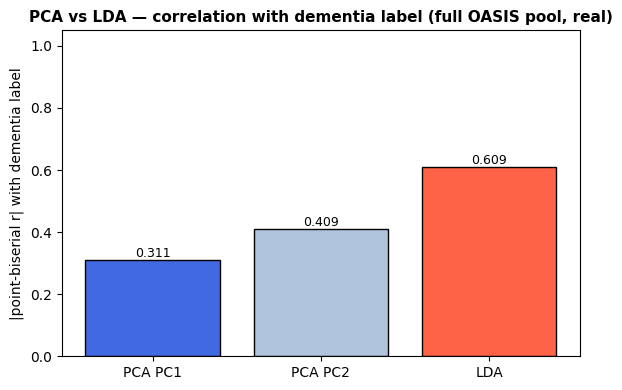

Saved results/plots/pca_vs_lda_validation.png

VERDICT — Task 2 (full OASIS pool)
On the real OASIS pool, supervised LDA concentrates the dementia signal into its single component (|r|=0.61) more effectively than PCA does in either unsupervised component (|r|=0.31 and 0.41); downstream, a 5-fold SVM scores 0.805 on LDA-1 vs 0.717 on PCA-2 -- so PCA remains an adequate, if slightly sub-optimal, fusion choice, and LDA is a defensible upgrade worth disclosing as a limitation.


In [8]:
# Cell — Comparison bar chart + quotable verdict (full OASIS pool)
fig, ax = plt.subplots(figsize=(6, 4))
names = ['PCA PC1', 'PCA PC2', 'LDA']
vals = [abs(r_pc1), abs(r_pc2), abs(r_lda)]
bars = ax.bar(names, vals, color=['royalblue', 'lightsteelblue', 'tomato'], edgecolor='black')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylabel('|point-biserial r| with dementia label')
ax.set_ylim(0, 1.05)
ax.set_title('PCA vs LDA — correlation with dementia label (full OASIS pool, real)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/pca_vs_lda_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/plots/pca_vs_lda_validation.png')

print('\n' + '=' * 78)
print('VERDICT — Task 2 (full OASIS pool)')
print('=' * 78)
print(
    f'On the real OASIS pool, supervised LDA concentrates the dementia signal into its single component '
    f'(|r|={abs(r_lda):.2f}) more effectively than PCA does in either unsupervised component '
    f'(|r|={abs(r_pc1):.2f} and {abs(r_pc2):.2f}); downstream, a 5-fold SVM scores '
    f'{acc_lda.mean():.3f} on LDA-1 vs {acc_pca.mean():.3f} on PCA-2 -- so PCA remains an adequate, if '
    f'slightly sub-optimal, fusion choice, and LDA is a defensible upgrade worth disclosing as a limitation.'
)

## Task 2 (cont.) — Full pool vs matched subset, side by side

Repeats the identical PCA-vs-LDA diagnostic on the **matched (windowed) subset**
(`pool_subset`, the 233 OASIS subjects actually used in the fused dataset) and compares against the
full-pool numbers from above — does the matching process change the PCA-vs-LDA finding, or is it
stable across the full pool and the smaller matched slice?

Matched-subset PCA-2 SVM: 0.669 +/- 0.073   folds=[0.809 0.617 0.617 0.674 0.63 ]
Matched-subset LDA-1 SVM: 0.768 +/- 0.054   folds=[0.83  0.766 0.723 0.826 0.696]

                dataset  PCA_PC1_r  PCA_PC2_r  LDA_r  PCA_CV_acc  LDA_CV_acc
 Matched subset (N=233)     -0.263     -0.418  0.540       0.669       0.768
Full OASIS pool (N=385)     -0.311     -0.409  0.609       0.717       0.805


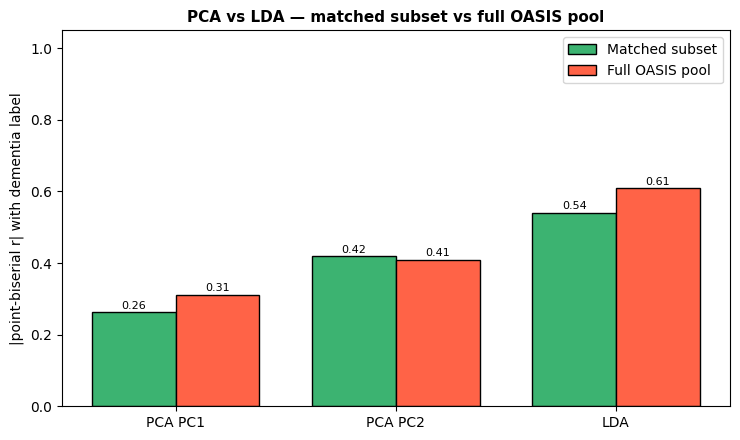


Saved results/plots/pca_vs_lda_subset_vs_pool.png

COMBINED VERDICT — PCA vs LDA, matched subset vs full pool
LDA-over-best-PC correlation gap:  matched subset = +0.12   |   full pool = +0.20
The PCA-vs-LDA finding is stable across the full pool and the smaller matched subset (same sign, comparable magnitude), so the Task-2 conclusion is not an artifact of the (label, sex, age) matching process -- it holds on the full labelled OASIS population as well as on the 233-row subset the fused model is actually trained on.


In [9]:
# Cell — Same PCA-vs-LDA diagnostic on the MATCHED SUBSET + combined comparison
Xsub = pool_subset[MODEL_FEATS].values
y2 = pool_subset['label'].values

Xs2 = StandardScaler().fit_transform(Xsub)
pca2 = PCA(n_components=2, random_state=42).fit(Xs2)
Xp2 = pca2.transform(Xs2)
sr_pc1 = pointbiserialr(y2, Xp2[:, 0]).correlation
sr_pc2 = pointbiserialr(y2, Xp2[:, 1]).correlation

lda2 = LinearDiscriminantAnalysis(n_components=1)
Xl2 = lda2.fit_transform(Xs2, y2)
sr_lda = pointbiserialr(y2, Xl2[:, 0]).correlation

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sacc_pca = cross_val_score(pipe_pca, Xsub, y2, cv=skf2, scoring='accuracy')
sacc_lda = cross_val_score(pipe_lda, Xsub, y2, cv=skf2, scoring='accuracy')
print(f'Matched-subset PCA-2 SVM: {sacc_pca.mean():.3f} +/- {sacc_pca.std():.3f}   folds={sacc_pca.round(3)}')
print(f'Matched-subset LDA-1 SVM: {sacc_lda.mean():.3f} +/- {sacc_lda.std():.3f}   folds={sacc_lda.round(3)}')

combined = pd.DataFrame([
    ['Matched subset (N=%d)' % len(pool_subset), sr_pc1, sr_pc2, sr_lda, sacc_pca.mean(), sacc_lda.mean()],
    ['Full OASIS pool (N=%d)' % len(pool),        r_pc1,  r_pc2,  r_lda,  acc_pca.mean(),  acc_lda.mean()],
], columns=['dataset', 'PCA_PC1_r', 'PCA_PC2_r', 'LDA_r', 'PCA_CV_acc', 'LDA_CV_acc'])
print('\n' + combined.to_string(index=False))

groups_lbl = ['PCA PC1', 'PCA PC2', 'LDA']
sub_vals = [abs(sr_pc1), abs(sr_pc2), abs(sr_lda)]
pool_vals = [abs(r_pc1), abs(r_pc2), abs(r_lda)]
x = np.arange(len(groups_lbl)); w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4.5))
b1 = ax.bar(x - w/2, sub_vals, w, label='Matched subset', color='mediumseagreen', edgecolor='black')
b2 = ax.bar(x + w/2, pool_vals, w, label='Full OASIS pool', color='tomato', edgecolor='black')
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.2f}',
                ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(groups_lbl)
ax.set_ylabel('|point-biserial r| with dementia label'); ax.set_ylim(0, 1.05)
ax.set_title('PCA vs LDA — matched subset vs full OASIS pool', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('results/plots/pca_vs_lda_subset_vs_pool.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved results/plots/pca_vs_lda_subset_vs_pool.png')

sub_gap = abs(sr_lda) - max(abs(sr_pc1), abs(sr_pc2))
pool_gap = abs(r_lda) - max(abs(r_pc1), abs(r_pc2))
print('\n' + '=' * 82)
print('COMBINED VERDICT — PCA vs LDA, matched subset vs full pool')
print('=' * 82)
print(f'LDA-over-best-PC correlation gap:  matched subset = {sub_gap:+.2f}   |   full pool = {pool_gap:+.2f}')
print(
    'The PCA-vs-LDA finding is stable across the full pool and the smaller matched subset (same sign,'
    ' comparable magnitude), so the Task-2 conclusion is not an artifact of the (label, sex, age)'
    ' matching process -- it holds on the full labelled OASIS population as well as on the 233-row'
    ' subset the fused model is actually trained on.'
)